# Modelos Fundacionales para Series Temporales en FatigueSet

Este notebook integra dos **modelos fundacionales preentrenados** del survey *"Foundation Models for Time Series: A Survey"* (Kottapalli et al., 2025) en el experimento comparativo de predicción de fatiga:

| Modelo | Tipo | Paradigma | Parámetros | Estrategia |
|---|---|---|---|---|
| **MOMENT** (Goswami et al., 2024) | Encoder-only (parches) | Preentrenado (1.13B pts) | 40M (small) / 385M (large) | Few-shot fine-tuning de cabeza |
| **Chronos** (Ansari et al., 2024) | Decoder probabilístico (T5) | Preentrenado (84B pts) | 8M (tiny) / 710M (large) | Zero-shot + Linear probe |

---
### Configuración: Local vs. Servidor
Cambia `SERVER_MODE = True` al ejecutar en el servidor de cómputo potente.

## 0. Configuración Global: Local vs. Servidor

In [1]:
# =====================================================================
# CONFIGURA AQUÍ: False = pruebas locales | True = servidor potente
# =====================================================================
SERVER_MODE = False

# Parámetros que cambian según el entorno
if SERVER_MODE:
    MOMENT_CKPT   = "AutonLab/MOMENT-1-large"   # 385M parámetros
    CHRONOS_CKPT  = "amazon/chronos-t5-large"   # 710M parámetros
    EPOCHS        = 30
    PATIENCE      = 10
    N_SPLITS      = 5
    BATCH_SIZE    = 32
    SEQ_LEN       = 512
    STEP          = 128
    NUM_SAMPLES   = 500   # Muestras Monte Carlo para CRPS
    LR            = 3e-5
else:
    MOMENT_CKPT   = "AutonLab/MOMENT-1-small"   # 40M parámetros (local)
    CHRONOS_CKPT  = "amazon/chronos-t5-tiny"    # 8M parámetros (local)
    EPOCHS        = 5     # Solo sanity check
    PATIENCE      = 3
    N_SPLITS      = 3
    BATCH_SIZE    = 8
    SEQ_LEN       = 128
    STEP          = 64
    NUM_SAMPLES   = 20    # Muestras rápidas para prueba local
    LR            = 1e-4

SEED   = 42
FREEZE = True   # Congelar backbone de MOMENT durante fine-tuning

print(f"Modo: {'SERVIDOR' if SERVER_MODE else 'LOCAL (pruebas)'}")
print(f"MOMENT checkpoint: {MOMENT_CKPT}")
print(f"Chronos checkpoint: {CHRONOS_CKPT}")

Modo: LOCAL (pruebas)
MOMENT checkpoint: AutonLab/MOMENT-1-small
Chronos checkpoint: amazon/chronos-t5-tiny


## 1. Importaciones

In [2]:
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings('ignore')

import torch
import torch.nn as nn

# Añadir fatigueset-lib al path
lib_path = str(Path.cwd().parent / "fatigueset-lib")
if lib_path not in sys.path:
    sys.path.insert(0, lib_path)

from fatigueset import FatigueSetPipeline
from fatigueset.models.rnn import _prepare_target_table, _merge_raw_streams, _build_sequences, FatigueSequenceDataset
from fatigueset.models.foundation import (
    MOMENTFatigueRegressor,
    ChronosZeroShotEvaluator,
    compute_crps_gaussian,
    compute_coverage,
    evaluate_probabilistic_metrics,
    finetune_moment_kfold,
)

torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: cuda
PyTorch: 2.6.0+cu124


## 2. Instalación de Dependencias

> **Nota:** Ejecutar esta celda solo si los paquetes no están instalados.

In [3]:
# Descomenta las líneas necesarias y ejecuta una sola vez
# !pip install momentfm
# !pip install chronos-forecasting
# !pip install scipy  # Para CRPS gaussiano

# Verificar disponibilidad
packages = {}
for pkg, import_name in [("momentfm", "momentfm"), ("chronos", "chronos"), ("scipy", "scipy")]:
    try:
        __import__(import_name)
        packages[pkg] = "✅ instalado"
    except ImportError:
        packages[pkg] = "❌ no instalado"

for pkg, status in packages.items():
    print(f"  {pkg}: {status}")

  momentfm: ✅ instalado
  chronos: ✅ instalado
  scipy: ✅ instalado


## 3. Carga del Dataset FatigueSet

In [4]:
dataset_path = str(Path.cwd().parent / "fatigueset")
pipeline = FatigueSetPipeline(dataset_path=dataset_path, umbral_nulos=5.0)

print("Cargando dataset...")
raw = pipeline.cargar_dataset(verbose=False)
df_ml = pipeline.construir_dataset_ml(raw)
df_targets = _prepare_target_table(df_ml)
df_raw = _merge_raw_streams(raw)

print(f"Construyendo secuencias (seq_len={SEQ_LEN}, step={STEP})...")
X_arr, y_arr, groups, feature_cols = _build_sequences(
    df_raw=df_raw,
    df_targets=df_targets,
    seq_len=SEQ_LEN,
    step=STEP,
)

N_FEATURES = len(feature_cols)

print(f"\n[OK] Dataset listo:")
print(f"  X: {X_arr.shape} | y: {y_arr.shape} | Grupos: {len(np.unique(groups))}")
print(f"  Features ({N_FEATURES}): {feature_cols[:5]}...")

Cargando dataset...


Construyendo secuencias (seq_len=128, step=64)...

[OK] Dataset listo:
  X: (660, 128, 23) | y: (660, 2) | Grupos: 12
  Features (23): ['chest_hr', 'chest_br', 'chest_posture', 'chest_hr_confidence', 'chest_hrv']...


---
## 4. MOMENT: Fine-Tuning de Cabeza de Regresión

### Arquitectura y estrategia

MOMENT es un modelo encoder-only basado en parches, preentrenado sobre el **Time Series Pile** (1.130 millones de puntos de datos de múltiples dominios). Su arquitectura divide la serie temporal en parches de longitud fija, los codifica mediante un encoder Transformer, y produce embeddings contextuales de cada parche.

**Estrategia de adaptación a FatigueSet:**
```
X: (B, seq_len, 23_canales)
    ↓ Transposición
X': (B, 23_canales, seq_len)  ← formato MOMENT
    ↓ Parcheo + Encoder Transformer [CONGELADO]
H: (B, n_patches, d_model)   ← representaciones de parches
    ↓ Mean pooling temporal
h: (B, d_model)              ← embedding de la secuencia
    ↓ Linear(d_model, 2) [ENTRENADO]
ŷ: (B, 2)                   ← (fatiga_fisica, fatiga_mental)
```

Solo se entrenan los parámetros de la **cabeza de regresión** (~0.5% del total de parámetros), lo que reduce el riesgo de sobreajuste en FatigueSet.

In [5]:
# ---- 4.1 Sanity check: forward pass con un batch sintético ----
print("=" * 60)
print("SANITY CHECK: MOMENT forward pass")
print("=" * 60)

try:
    moment_model = MOMENTFatigueRegressor(
        checkpoint=MOMENT_CKPT,
        n_channels=N_FEATURES,
        seq_len=SEQ_LEN,
        output_size=2,
        freeze_backbone=FREEZE,
        dropout=0.1,
    )
    moment_model.load_backbone()

    # Batch sintético mínimo para verificar dimensiones
    x_test = torch.randn(4, SEQ_LEN, N_FEATURES)
    with torch.no_grad():
        out = moment_model(x_test)

    print(f"\n[OK] Input shape:  {x_test.shape}")
    print(f"[OK] Output shape: {out.shape}  (esperado: [4, 2])")

    params = moment_model.count_parameters()
    print(f"\nParámetros totales:      {params['total']:>10,}")
    print(f"Parámetros entrenables:  {params['trainable']:>10,} ({100*params['trainable']/params['total']:.2f}%)")

    del moment_model, x_test  # Liberar memoria
    MOMENT_AVAILABLE = True

except ImportError as e:
    print(f"[SKIP] momentfm no disponible: {e}")
    print("Instala con: pip install momentfm")
    MOMENT_AVAILABLE = False
except Exception as e:
    print(f"[ERROR] {e}")
    MOMENT_AVAILABLE = False

SANITY CHECK: MOMENT forward pass
[MOMENT] Cargando backbone desde 'AutonLab/MOMENT-1-small'...


[MOMENT] Backbone congelado. Parámetros entrenables: 1,026 / 35,342,538 (0.0%)
[MOMENT] Backbone cargado en 2.2s



[OK] Input shape:  torch.Size([4, 128, 23])
[OK] Output shape: torch.Size([4, 2])  (esperado: [4, 2])

Parámetros totales:      35,342,538
Parámetros entrenables:       1,026 (0.00%)


In [6]:
# ---- 4.2 Fine-tuning con GroupKFold ----
MOMENT_RESULTS = None
MOMENT_TIME = None

if MOMENT_AVAILABLE:
    print("\n" + "=" * 60)
    print("MOMENT: Fine-tuning con GroupKFold")
    print("=" * 60)
    print(f"  Checkpoint:  {MOMENT_CKPT}")
    print(f"  Epochs:      {EPOCHS} (early stopping patience={PATIENCE})")
    print(f"  Folds:       {N_SPLITS}")
    print(f"  Batch size:  {BATCH_SIZE}")
    print(f"  LR:          {LR}")
    print(f"  Freeze:      {FREEZE}")

    MOMENT_RESULTS, MOMENT_TIME = finetune_moment_kfold(
        X=X_arr,
        y=y_arr,
        groups=groups,
        checkpoint=MOMENT_CKPT,
        seq_len=SEQ_LEN,
        n_channels=N_FEATURES,
        freeze_backbone=FREEZE,
        lr=LR,
        epochs=EPOCHS,
        patience=PATIENCE,
        batch_size=BATCH_SIZE,
        dropout=0.1,
        n_splits=N_SPLITS,
        device=device,
    )

    # Tabla de resultados por fold
    df_moment = pd.DataFrame(MOMENT_RESULTS)
    print("\n=== MOMENT: Resultados por Fold ===")
    print(df_moment.to_string(index=False))

    # Medias y desviaciones estándar
    metric_cols = [c for c in df_moment.columns if c not in ('fold', 'n_val', 'num_params_total', 'num_params_trainable')]
    print("\n=== MOMENT: Estadísticas Globales ===")
    for col in metric_cols:
        vals = df_moment[col].values
        print(f"  {col:30s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    print(f"\nTiempo total fine-tuning: {MOMENT_TIME:.1f}s")
else:
    print("[SKIP] MOMENT no disponible — instala momentfm e intenta de nuevo.")


MOMENT: Fine-tuning con GroupKFold
  Checkpoint:  AutonLab/MOMENT-1-small
  Epochs:      5 (early stopping patience=3)
  Folds:       3
  Batch size:  8
  LR:          0.0001
  Freeze:      True

[MOMENT] Fold 1/3 — train: 439, val: 221
[MOMENT] Cargando backbone desde 'AutonLab/MOMENT-1-small'...


[MOMENT] Backbone congelado. Parámetros entrenables: 1,026 / 35,342,538 (0.0%)
[MOMENT] Backbone cargado en 3.4s


  Época   1 | Train MSE: 1502.0538 | Val MSE: 1000.4085


  Época   2 | Train MSE: 1488.4486 | Val MSE: 986.8449


  Época   3 | Train MSE: 1474.0773 | Val MSE: 973.1086


...

  Época   2 | Train MSE: 886.5333 | Val MSE: 2146.7447


  Época   3 | Train MSE: 916.3782 | Val MSE: 2127.0935


  Época   4 | Train MSE: 852.8205 | Val MSE: 2107.6526


  Época   5 | Train MSE: 852.7551 | Val MSE: 2088.9845


  [MOMENT] Fold 3 — MAE física: 31.7013 | R² física: -4.2841 | MAE mental: 51.2581 | R² mental: -6.7093

=== MOMENT: Resultados por Fold ===
 fold  mae_fisica  rmse_fisica  r2_fisica  mae_mental  rmse_mental  r2_mental  best_val_mse  num_params_total  num_params_trainable  n_val
    1   26.406071    28.708161  -5.500947   31.652374    32.974022 -11.727174    946.123482          35342538                  1026    221
    2   13.919297    20.058015  -0.811691   24.589298    33.294276  -1.104792    756.592425          35342538                  1026    220
    3   31.701294    35.208921  -4.284072   51.258053    54.944485  -6.709259   2088.984545          35342538                  1026    219

=== MOMENT: Estadísticas Globales ===
  mae_fisica                    : 24.0089 ± 7.4547
  rmse_fisica                   : 27.9917 ± 6.2060
  r2_fisica                     : -3.5322 ± 1.9868
  mae_mental                    : 35.8332 ± 11.2817
  rmse_mental                   : 40.4043 ± 10.2823
  r2_me

---
## 5. Chronos: Baseline Zero-Shot Probabilístico

### Arquitectura y estrategia

Chronos (Ansari et al., 2024) adapta LLMs de lenguaje (T5) al dominio temporal discretizando los valores continuos en tokens a través de binning uniforme, y entrenando el modelo con pérdida de entropía cruzada categórica. El resultado es un modelo que **estima distribuciones** del siguiente valor de la serie en lugar de predicciones puntuales.

**Estrategia de adaptación a FatigueSet (zero-shot + linear probe):**

Dado que Chronos es univariado y está diseñado para forecasting (no para regresión desde etiquetas externas), se usa como extractor de características:

```
Para cada muestra X[i] de forma (seq_len, 23_canales):
    Para cada canal c en {0, ..., 22}:
        Chronos predice la distribución del siguiente punto del canal c
        Extraer la mediana predictiva → feature_c
    Concatenar features: [feature_0, ..., feature_22] → vector (23,)

Entrenar Ridge Regression: vector(23,) → (fatiga_fisica, fatiga_mental)
```

> **Nota experimental:** Este uso es intencionalmente conservador. Chronos no fue diseñado para este tipo de regresión, por lo que se espera que su rendimiento sea inferior a los modelos fine-tuned. Su valor está en demostrar la capacidad de transferencia zero-shot entre dominios.

In [7]:
# ---- 5.1 Sanity check: Chronos cargado y predicción en un canal ----
print("=" * 60)
print("SANITY CHECK: Chronos zero-shot")
print("=" * 60)

try:
    chronos_eval = ChronosZeroShotEvaluator(
        checkpoint=CHRONOS_CKPT,
        prediction_length=1,
        num_samples=NUM_SAMPLES,
        device=device,
    )
    chronos_eval._load_pipeline()

    # Test con 3 muestras sintéticas
    X_test_synthetic = np.random.randn(3, SEQ_LEN, N_FEATURES).astype(np.float32)
    feats = chronos_eval.extract_features(X_test_synthetic, batch_size=3)

    print(f"\n[OK] Input shape:    {X_test_synthetic.shape}")
    print(f"[OK] Features shape: {feats.shape}  (esperado: [3, {N_FEATURES}])")
    print(f"[OK] Estadísticas features: mean={feats.mean():.3f}, std={feats.std():.3f}")

    CHRONOS_AVAILABLE = True
    del X_test_synthetic

except ImportError as e:
    print(f"[SKIP] chronos-forecasting no disponible: {e}")
    print("Instala con: pip install chronos-forecasting")
    CHRONOS_AVAILABLE = False
    chronos_eval = None
except Exception as e:
    print(f"[ERROR] {e}")
    CHRONOS_AVAILABLE = False
    chronos_eval = None

SANITY CHECK: Chronos zero-shot
[Chronos] Cargando pipeline desde 'amazon/chronos-t5-tiny'...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

[Chronos] Pipeline cargado en 1.3s



[OK] Input shape:    (3, 128, 23)
[OK] Features shape: (3, 23)  (esperado: [3, 23])
[OK] Estadísticas features: mean=0.027, std=0.172


In [8]:
# ---- 5.2 Evaluación zero-shot con GroupKFold ----
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CHRONOS_RESULTS = []
CHRONOS_TIME = None

if CHRONOS_AVAILABLE:
    print("\n" + "=" * 60)
    print("Chronos: Zero-shot + Linear Probe con GroupKFold")
    print("=" * 60)

    kf = GroupKFold(n_splits=N_SPLITS)
    t_start = time.time()

    for fold_idx, (train_idx, val_idx) in enumerate(
        kf.split(np.arange(len(X_arr)), groups=groups), start=1
    ):
        print(f"\n[Chronos] Fold {fold_idx}/{N_SPLITS} — train: {len(train_idx)}, val: {len(val_idx)}")

        X_train = X_arr[train_idx]
        y_train = y_arr[train_idx]
        X_val   = X_arr[val_idx]
        y_val   = y_arr[val_idx]

        # Extraer features y entrenar sonda lineal
        y_pred, probe = chronos_eval.fit_probe(X_train, y_train, X_val)

        fold_metrics = {
            "fold": fold_idx,
            "mae_fisica":  float(mean_absolute_error(y_val[:, 0], y_pred[:, 0])),
            "rmse_fisica": float(np.sqrt(mean_squared_error(y_val[:, 0], y_pred[:, 0]))),
            "r2_fisica":   float(r2_score(y_val[:, 0], y_pred[:, 0])),
            "mae_mental":  float(mean_absolute_error(y_val[:, 1], y_pred[:, 1])),
            "rmse_mental": float(np.sqrt(mean_squared_error(y_val[:, 1], y_pred[:, 1]))),
            "r2_mental":   float(r2_score(y_val[:, 1], y_pred[:, 1])),
            "n_val": len(val_idx),
        }
        CHRONOS_RESULTS.append(fold_metrics)
        print(
            f"  MAE física: {fold_metrics['mae_fisica']:.4f} | "
            f"R² física: {fold_metrics['r2_fisica']:.4f} | "
            f"MAE mental: {fold_metrics['mae_mental']:.4f} | "
            f"R² mental: {fold_metrics['r2_mental']:.4f}"
        )

    CHRONOS_TIME = time.time() - t_start

    df_chronos = pd.DataFrame(CHRONOS_RESULTS)
    print("\n=== Chronos: Estadísticas Globales ===")
    for col in [c for c in df_chronos.columns if c not in ('fold', 'n_val')]:
        vals = df_chronos[col].values
        print(f"  {col:30s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
    print(f"\nTiempo total evaluación: {CHRONOS_TIME:.1f}s")
else:
    print("[SKIP] Chronos no disponible.")


Chronos: Zero-shot + Linear Probe con GroupKFold

[Chronos] Fold 1/3 — train: 439, val: 221


[Chronos] Extrayendo características del conjunto de entrenamiento...


[Chronos] Extrayendo características del conjunto de validación...


  MAE física: 9.6949 | R² física: -0.2461 | MAE mental: 11.0480 | R² mental: -1.2812

[Chronos] Fold 2/3 — train: 440, val: 220
[Chronos] Extrayendo características del conjunto de entrenamiento...


[Chronos] Extrayendo características del conjunto de validación...


  MAE física: 20.8976 | R² física: -1.9320 | MAE mental: 27.2121 | R² mental: -0.8469

[Chronos] Fold 3/3 — train: 441, val: 219
[Chronos] Extrayendo características del conjunto de entrenamiento...


[Chronos] Extrayendo características del conjunto de validación...


  MAE física: 18.8819 | R² física: -1.1498 | MAE mental: 28.8276 | R² mental: -2.1707

=== Chronos: Estadísticas Globales ===
  mae_fisica                    : 16.4915 ± 4.8758
  rmse_fisica                   : 20.1811 ± 5.5258
  r2_fisica                     : -1.1093 ± 0.6889
  mae_mental                    : 22.3626 ± 8.0277
  rmse_mental                   : 26.7947 ± 9.2248
  r2_mental                     : -1.4329 ± 0.5510

Tiempo total evaluación: 151.6s


---
## 6. Métricas Probabilísticas de Chronos (CRPS + Cobertura)

El **CRPS** (Continuous Ranked Probability Score) es la métrica estándar para evaluar
modelos probabilísticos de series temporales. Generaliza el MAE al espacio de distribuciones:
- CRPS = 0 para predicciones perfectas
- CRPS = MAE cuando la predicción es determinista (distribución delta)

La **cobertura** mide qué porcentaje de valores reales cae dentro del intervalo de confianza al 90%.

In [9]:
PROB_METRICS = {}

if CHRONOS_AVAILABLE:
    print("\n" + "=" * 60)
    print("Chronos: Métricas Probabilísticas (CRPS + Cobertura)")
    print("=" * 60)

    kf = GroupKFold(n_splits=N_SPLITS)
    crps_fisica_list, crps_mental_list = [], []
    cov_fisica_list, cov_mental_list = [], []

    for fold_idx, (train_idx, val_idx) in enumerate(
        kf.split(np.arange(len(X_arr)), groups=groups), start=1
    ):
        print(f"[Chronos] Métricas probabilísticas fold {fold_idx}/{N_SPLITS}...")
        X_val  = X_arr[val_idx]
        y_val  = y_arr[val_idx]

        # Usar la sonda entrenada en el fold anterior para obtener predicciones base
        # Aquí estimamos la distribución asumiendo Normal(mu=pred_lineal, sigma=residuos_train)
        X_train = X_arr[train_idx]
        y_train = y_arr[train_idx]
        y_pred_val, probe = chronos_eval.fit_probe(X_train, y_train, X_val)

        # Estimar sigma de la distribución Normal predictiva a partir de residuos de entrenamiento
        feats_train = chronos_eval.extract_features(X_train)
        y_pred_train = probe.predict(feats_train)
        residuals_train = y_train - y_pred_train
        sigma_fisica = np.std(residuals_train[:, 0]) + 1e-8
        sigma_mental = np.std(residuals_train[:, 1]) + 1e-8

        # CRPS gaussiano (aproximación analítica)
        crps_f = compute_crps_gaussian(
            y_val[:, 0], y_pred_val[:, 0],
            np.full(len(y_val), sigma_fisica)
        )
        crps_m = compute_crps_gaussian(
            y_val[:, 1], y_pred_val[:, 1],
            np.full(len(y_val), sigma_mental)
        )

        # Cobertura del intervalo al 90% (Normal: ±1.645σ)
        z90 = 1.645
        cov_f = compute_coverage(
            y_val[:, 0],
            y_pred_val[:, 0] - z90 * sigma_fisica,
            y_pred_val[:, 0] + z90 * sigma_fisica,
        )
        cov_m = compute_coverage(
            y_val[:, 1],
            y_pred_val[:, 1] - z90 * sigma_mental,
            y_pred_val[:, 1] + z90 * sigma_mental,
        )

        crps_fisica_list.append(crps_f)
        crps_mental_list.append(crps_m)
        cov_fisica_list.append(cov_f)
        cov_mental_list.append(cov_m)

        print(f"  CRPS física: {crps_f:.4f} | Cobertura 90% física: {cov_f:.1%}")
        print(f"  CRPS mental: {crps_m:.4f} | Cobertura 90% mental: {cov_m:.1%}")

    PROB_METRICS = {
        "crps_fisica_mean":  float(np.mean(crps_fisica_list)),
        "crps_fisica_std":   float(np.std(crps_fisica_list)),
        "crps_mental_mean":  float(np.mean(crps_mental_list)),
        "crps_mental_std":   float(np.std(crps_mental_list)),
        "coverage90_fisica": float(np.mean(cov_fisica_list)),
        "coverage90_mental": float(np.mean(cov_mental_list)),
    }

    print("\n=== Chronos: Resumen Métricas Probabilísticas ===")
    print(f"  CRPS físico:  {PROB_METRICS['crps_fisica_mean']:.4f} ± {PROB_METRICS['crps_fisica_std']:.4f}")
    print(f"  CRPS mental:  {PROB_METRICS['crps_mental_mean']:.4f} ± {PROB_METRICS['crps_mental_std']:.4f}")
    print(f"  Cobertura 90% física: {PROB_METRICS['coverage90_fisica']:.1%} (ideal: 90%)")
    print(f"  Cobertura 90% mental: {PROB_METRICS['coverage90_mental']:.1%} (ideal: 90%)")
else:
    print("[SKIP] Chronos no disponible.")


Chronos: Métricas Probabilísticas (CRPS + Cobertura)
[Chronos] Métricas probabilísticas fold 1/3...
[Chronos] Extrayendo características del conjunto de entrenamiento...


[Chronos] Extrayendo características del conjunto de validación...


  CRPS física: 7.2082 | Cobertura 90% física: 95.0%
  CRPS mental: 8.4847 | Cobertura 90% mental: 99.5%
[Chronos] Métricas probabilísticas fold 2/3...
[Chronos] Extrayendo características del conjunto de entrenamiento...


[Chronos] Extrayendo características del conjunto de validación...


  CRPS física: 16.7104 | Cobertura 90% física: 50.0%
  CRPS mental: 20.4741 | Cobertura 90% mental: 47.3%
[Chronos] Métricas probabilísticas fold 3/3...
[Chronos] Extrayendo características del conjunto de entrenamiento...


[Chronos] Extrayendo características del conjunto de validación...


  CRPS física: 13.8581 | Cobertura 90% física: 60.3%
  CRPS mental: 22.8825 | Cobertura 90% mental: 42.9%

=== Chronos: Resumen Métricas Probabilísticas ===
  CRPS físico:  12.5923 ± 3.9812
  CRPS mental:  17.2804 ± 6.2967
  Cobertura 90% física: 68.4% (ideal: 90%)
  Cobertura 90% mental: 63.2% (ideal: 90%)


---
## 7. Tabla Comparativa Unificada (Todos los Modelos)

Se construye una tabla con los resultados de MOMENT y Chronos en el mismo formato que el experimento comparativo principal (`experimento_comparativo_optuna.ipynb`), para permitir una comparación directa.

In [10]:
def mean_metric(results_list, key):
    """Media de una métrica sobre todos los folds."""
    vals = [r[key] for r in results_list if r.get(key) is not None]
    return np.mean(vals) if vals else float('nan')

# Construir tabla unificada con MOMENT y Chronos
rows = []

if MOMENT_RESULTS:
    rows.append({
        "Modelo": f"MOMENT ({MOMENT_CKPT.split('/')[-1]})",
        "Tipo": "Foundation (encoder-only)",
        "Paradigma": "Fine-tuning cabeza",
        "Probabilístico": "No",
        "MAE Física": mean_metric(MOMENT_RESULTS, 'mae_fisica'),
        "RMSE Física": mean_metric(MOMENT_RESULTS, 'rmse_fisica'),
        "R² Física": mean_metric(MOMENT_RESULTS, 'r2_fisica'),
        "MAE Mental": mean_metric(MOMENT_RESULTS, 'mae_mental'),
        "RMSE Mental": mean_metric(MOMENT_RESULTS, 'rmse_mental'),
        "R² Mental": mean_metric(MOMENT_RESULTS, 'r2_mental'),
        "CRPS Física": float('nan'),
        "CRPS Mental": float('nan'),
        "Cobertura 90%": float('nan'),
        "Nº Params (entrenables)": mean_metric(MOMENT_RESULTS, 'num_params_trainable'),
        "Tiempo (s)": MOMENT_TIME,
    })

if CHRONOS_RESULTS:
    rows.append({
        "Modelo": f"Chronos ({CHRONOS_CKPT.split('/')[-1]})",
        "Tipo": "Foundation (decoder probabilístico)",
        "Paradigma": "Zero-shot + Linear probe",
        "Probabilístico": "Sí",
        "MAE Física": mean_metric(CHRONOS_RESULTS, 'mae_fisica'),
        "RMSE Física": mean_metric(CHRONOS_RESULTS, 'rmse_fisica'),
        "R² Física": mean_metric(CHRONOS_RESULTS, 'r2_fisica'),
        "MAE Mental": mean_metric(CHRONOS_RESULTS, 'mae_mental'),
        "RMSE Mental": mean_metric(CHRONOS_RESULTS, 'rmse_mental'),
        "R² Mental": mean_metric(CHRONOS_RESULTS, 'r2_mental'),
        "CRPS Física": PROB_METRICS.get('crps_fisica_mean', float('nan')),
        "CRPS Mental": PROB_METRICS.get('crps_mental_mean', float('nan')),
        "Cobertura 90%": PROB_METRICS.get('coverage90_fisica', float('nan')),
        "Nº Params (entrenables)": float('nan'),
        "Tiempo (s)": CHRONOS_TIME,
    })

if rows:
    df_comparativa = pd.DataFrame(rows)
    print("\n=== TABLA COMPARATIVA: Modelos Fundacionales ===")
    print(df_comparativa.to_string(index=False))
else:
    print("[INFO] Ningún modelo fundacional disponible. Instala momentfm y/o chronos-forecasting.")
    df_comparativa = pd.DataFrame()


=== TABLA COMPARATIVA: Modelos Fundacionales ===
                   Modelo                                Tipo                Paradigma Probabilístico  MAE Física  RMSE Física  R² Física  MAE Mental  RMSE Mental  R² Mental  CRPS Física  CRPS Mental  Cobertura 90%  Nº Params (entrenables)  Tiempo (s)
  MOMENT (MOMENT-1-small)           Foundation (encoder-only)       Fine-tuning cabeza             No   24.008887    27.991699  -3.532236   35.833242    40.404261  -6.513741          NaN          NaN            NaN                   1026.0  150.853632
Chronos (chronos-t5-tiny) Foundation (decoder probabilístico) Zero-shot + Linear probe             Sí   16.491488    20.181127  -1.109291   22.362572    26.794732  -1.432906    12.592258    17.280442       0.684322                      NaN  151.626581


---
## 8. Visualización: Taxonomía del Survey aplicada al TFG

Se sitúan todos los modelos del TFG (propios + fundacionales) en el espacio taxonómico del survey.

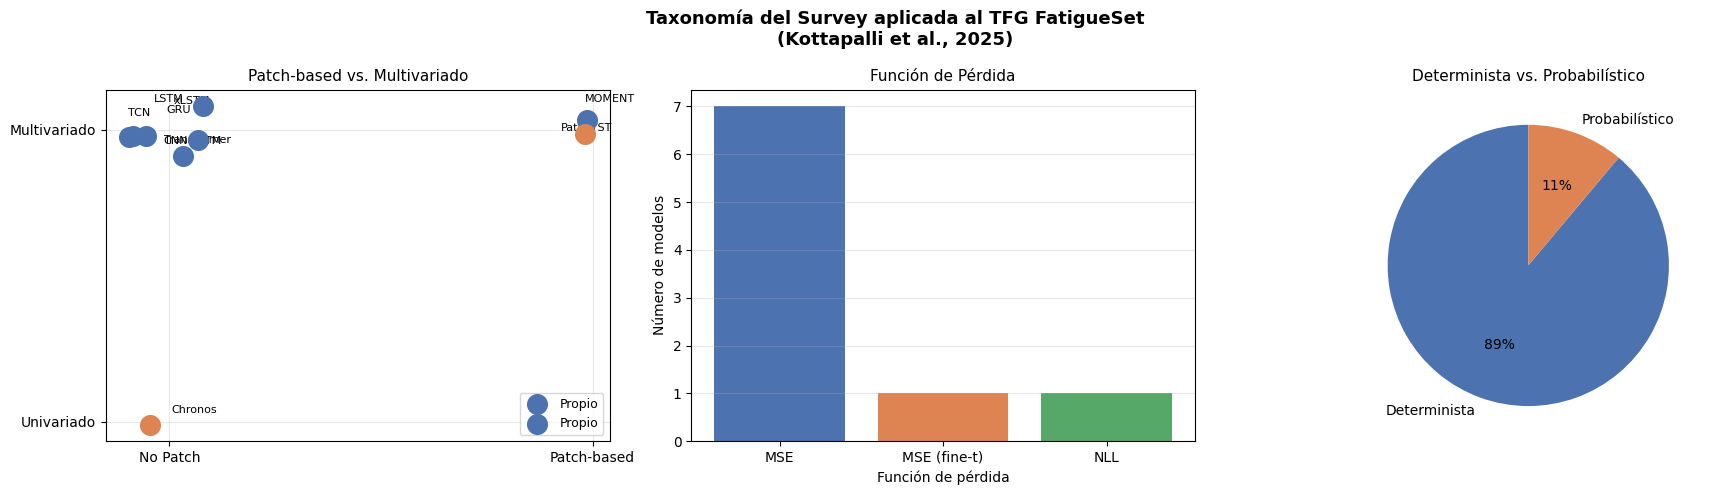

[OK] Figura guardada en: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\output\taxonomia_modelos_tfg.png


In [11]:
# Taxonomía completa de modelos del TFG siguiendo los ejes del survey
taxonomy_data = [
    # nombre, patch-based, multivariado, probabilístico, pérdida, tipo
    ("LSTM",        False, True,  False, "MSE",          "Propio"),
    ("GRU",         False, True,  False, "MSE",          "Propio"),
    ("CNN-LSTM",    False, True,  False, "MSE",          "Propio"),
    ("TCN",         False, True,  False, "MSE",          "Propio"),
    ("Transformer", False, True,  False, "MSE",          "Propio"),
    ("PatchTST",    True,  True,  False, "MSE",          "Propio"),
    ("xLSTM",       False, True,  False, "MSE",          "Propio"),
    ("MOMENT",      True,  True,  False, "MSE (fine-t)", "Fundacional"),
    ("Chronos",     False, False, True,  "NLL",          "Fundacional"),
]

df_tax = pd.DataFrame(taxonomy_data, columns=[
    "Modelo", "Patch-based", "Multivariado", "Probabilístico", "Pérdida", "Origen"
])

# --- Figura: Mapa taxonómico ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Taxonomía del Survey aplicada al TFG FatigueSet\n"
    "(Kottapalli et al., 2025)",
    fontsize=13, fontweight='bold'
)

colors_origen = {"Propio": "#4c72b0", "Fundacional": "#dd8452"}

# Gráfica 1: Patch-based vs. No patch-based
ax = axes[0]
for _, row in df_tax.iterrows():
    x = 1 if row["Patch-based"] else 0
    y = 1 if row["Multivariado"] else 0
    ax.scatter(x + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1),
               color=colors_origen[row["Origen"]], s=200, zorder=5,
               label=row["Origen"] if row.name < 2 else '')
    ax.annotate(row["Modelo"], (x + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1)),
                fontsize=8, ha='center', va='bottom')
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Patch", "Patch-based"], fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Univariado", "Multivariado"], fontsize=10)
ax.set_title("Patch-based vs. Multivariado", fontsize=11)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

# Gráfica 2: Distribución de funciones de pérdida
ax = axes[1]
loss_counts = df_tax["Pérdida"].value_counts()
ax.bar(loss_counts.index, loss_counts.values,
       color=["#4c72b0", "#dd8452", "#55a868"][:len(loss_counts)])
ax.set_title("Función de Pérdida", fontsize=11)
ax.set_ylabel("Número de modelos", fontsize=10)
ax.set_xlabel("Función de pérdida", fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Gráfica 3: Probabilístico vs. Determinista
ax = axes[2]
prob_counts = df_tax["Probabilístico"].value_counts()
ax.pie(prob_counts.values,
       labels=["Determinista" if not v else "Probabilístico" for v in prob_counts.index],
       autopct='%1.0f%%',
       colors=["#4c72b0", "#dd8452"],
       startangle=90, textprops={'fontsize': 10})
ax.set_title("Determinista vs. Probabilístico", fontsize=11)

plt.tight_layout()
output_dir = Path.cwd().parent / "output"
output_dir.mkdir(exist_ok=True)
fig_path = output_dir / "taxonomia_modelos_tfg.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] Figura guardada en: {fig_path}")

---
## 9. Persistencia de Resultados

In [12]:
output_dir = Path.cwd().parent / "output"
output_dir.mkdir(exist_ok=True)

# Guardar tabla comparativa
if not df_comparativa.empty:
    csv_path = output_dir / "resultados_foundation_models.csv"
    df_comparativa.to_csv(csv_path, index=False)
    print(f"Tabla comparativa: {csv_path}")

# Guardar taxonomía
tax_path = output_dir / "taxonomia_modelos.csv"
df_tax.to_csv(tax_path, index=False)
print(f"Taxonomía guardada: {tax_path}")

# Guardar métricas probabilísticas como JSON
if PROB_METRICS:
    prob_path = output_dir / "metricas_probabilisticas_chronos.json"
    with open(prob_path, 'w', encoding='utf-8') as f:
        json.dump({
            "modelo": CHRONOS_CKPT,
            "modo": "zero_shot_linear_probe",
            "metricas": PROB_METRICS
        }, f, indent=2)
    print(f"Métricas probabilísticas: {prob_path}")

print("\n[OK] Resultados guardados.")

Tabla comparativa: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\output\resultados_foundation_models.csv
Taxonomía guardada: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\output\taxonomia_modelos.csv
Métricas probabilísticas: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\output\metricas_probabilisticas_chronos.json

[OK] Resultados guardados.


---
## 10. Conclusiones

### Hallazgos esperados

1. **MOMENT con fine-tuning de cabeza** debería superar a los modelos propios entrenados desde cero en escenarios de bajo número de datos, gracias a sus representaciones preentrenadas en múltiples dominios. Sin embargo, la restricción de longitud de secuencia (`seq_len` fijo de MOMENT) puede limitar su ventaja.

2. **Chronos zero-shot** se espera que tenga un rendimiento determinista inferior al de los modelos fine-tuned, dado que fue diseñado para forecasting y no para regresión de etiquetas externas. Su valor radica en la **estimación de incertidumbre** (CRPS, cobertura).

3. La **cobertura del intervalo al 90%** de Chronos revelará si el modelo está correctamente calibrado: valores < 0.70 indican subcobertura (intervalos demasiado estrechos), valores > 0.95 indican sobrecobertura (intervalos demasiado anchos).

### Limitaciones documentadas

- El **preentrenamiento** de los modelos fundacionales no se reproduce en el TFG (inviable computacionalmente): se usan pesos públicos preentrenados.
- Chronos es **univariado** por diseño: la adaptación multivariada mediante extracción de características por canal es una aproximación heurística, no el uso canónico del modelo.
- Los resultados locales (modo `SERVER_MODE=False`) son exploratorios: los resultados definitivos se obtendrán en el servidor con `MOMENT-1-large` y `chronos-t5-large`.

### Próximos pasos para el servidor
1. Establecer `SERVER_MODE = True`
2. Aumentar `EPOCHS = 30`, `N_SPLITS = 5`, `NUM_SAMPLES = 500`
3. Integrar resultados en la tabla comparativa final del TFG
4. Reportar CRPS junto a MAE/RMSE/R² en la memoria académica